#PCA

전체 데이터: (52120, 39)
미드 데이터: (10424, 39)
     PC  explained_variance_ratio  cumulative_variance
0   PC1                  0.246507             0.246507
1   PC2                  0.130183             0.376690
2   PC3                  0.091561             0.468251
3   PC4                  0.075607             0.543858
4   PC5                  0.056312             0.600169
5   PC6                  0.050530             0.650699
6   PC7                  0.045359             0.696058
7   PC8                  0.045059             0.741117
8   PC9                  0.038714             0.779831
9  PC10                  0.038071             0.817902


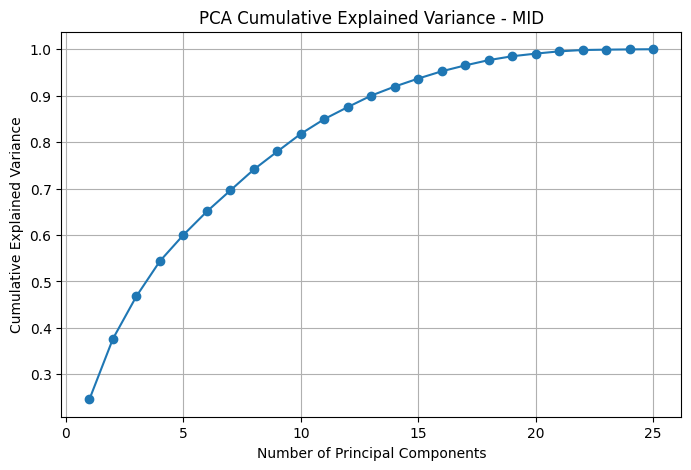

   playername            teamname  year league  result       PC1       PC2  \
2      Frozen  Incredible Miracle  2016    LCK       1 -3.181805 -2.445135   
7        Kyle         Dark Wolves  2016    LCK       0 -4.631734 -2.073687   
12       Kyle         Dark Wolves  2016    LCK       1 -2.118240 -2.909918   
17     Frozen  Incredible Miracle  2016    LCK       0 -3.232197 -2.916546   
22     Frozen  Incredible Miracle  2016    LCK       1 -0.089486 -3.047240   

         PC3  
2  -1.362795  
7  -1.687971  
12 -1.645708  
17  0.122880  
22 -3.013890  
                               PC1       PC2       PC3
earned gpm                0.303516 -0.104059  0.034837
goldat15                  0.298328 -0.142657  0.014921
golddiffat15              0.283623 -0.147942 -0.051266
csat15                    0.282989 -0.061125  0.015189
xpat15                    0.278083 -0.086991  0.036092
xpdiffat15                0.263623 -0.145326 -0.040568
csdiffat15                0.262258 -0.156732 -0.060094
c

In [42]:
import pandas as pd
import numpy as np
import glob
import os

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. CSV 파일 불러오기
files = sorted(
    glob.glob("/content/drive/MyDrive/전처리한 oracle 데이터/*.csv")
)

files = [f for f in files if os.path.isfile(f)]

df_list = []
for file in files:
    temp = pd.read_csv(file)
    if len(temp) > 0:
        df_list.append(temp)

df = pd.concat(df_list, ignore_index=True)

# 2. 미드 데이터만 필터링
mid_df = df[df["position"].str.lower() == "mid"].copy()

print("전체 데이터:", df.shape)
print("미드 데이터:", mid_df.shape)

# 3. PCA에 사용할 feature 선택
features = [
    "golddiffat15", "xpdiffat15", "csdiffat15",
    "goldat15", "xpat15", "csat15",
    "dpm", "damageshare",
    "damagetakenperminute", "damagemitigatedperminute",
    "visionscore", "vspm",
    "wardsplaced", "wardskilled",
    "wpm", "wcpm",
    "controlwardsbought",
    "earnedgold", "earned gpm", "earnedgoldshare",
    "cspm", "damagetotowers",
    "firstbloodkill", "firstbloodassist", "firstbloodvictim"
]

X = mid_df[features].copy()

# 4. 결측치 처리
X = X.fillna(X.mean())

# 5. 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 6. PCA 실행
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 7. 설명된 분산 비율 확인
explained = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_variance": np.cumsum(pca.explained_variance_ratio_)
})

print(explained.head(10))

# 8. 누적 설명력 그래프
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    np.cumsum(pca.explained_variance_ratio_),
    marker="o"
)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance - MID")
plt.grid(True)
plt.show()

# 9. 일단 PC 3개만 사용
pca_3 = PCA(n_components=3)
X_pca_3 = pca_3.fit_transform(X_scaled)

mid_pca = mid_df[["playername", "teamname", "year", "league", "result"]].copy()

mid_pca["PC1"] = X_pca_3[:, 0]
mid_pca["PC2"] = X_pca_3[:, 1]
mid_pca["PC3"] = X_pca_3[:, 2]

print(mid_pca.head())

# 10. PCA loading 확인
loadings = pd.DataFrame(
    pca_3.components_.T,
    index=features,
    columns=["PC1", "PC2", "PC3"]
)

print(loadings.sort_values("PC1", ascending=False))

# 11. PC별 영향 큰 feature 보기
for pc in ["PC1", "PC2", "PC3"]:
    print(f"\n===== {pc} 양의 방향 =====")
    print(loadings[pc].sort_values(ascending=False).head(7))

    print(f"\n===== {pc} 음의 방향 =====")
    print(loadings[pc].sort_values().head(7))

# 12. 선수별 평균 PCA 점수
player_pca = mid_pca.groupby("playername")[["PC1", "PC2", "PC3"]].mean()

print(player_pca.sort_values("PC1", ascending=False).head(20))



#PCA 결과 해석
[1] PC1 해석: 성장력 / 캐리력 축

PC1의 높은 loading feature:
- earned gpm
- goldat15
- golddiffat15
- csat15
- xpat15
- xpdiffat15
- csdiffat15

→ 라인전 우위, CS 수급, 골드 성장, 경험치 확보 능력을 나타냄.

즉 PC1이 높을수록:
- 라인전 dominance가 강하고
- resource generation 능력이 뛰어나며
- carry 중심 플레이 성향을 가진다고 해석 가능.

대표 선수:
- Chovy
- Scout
- Zeka
- ShowMaker

특히 Chovy는 PC1 점수가 매우 높게 나타났으며,
이는 실제 경기에서 보이는 강력한 라인전 및 성장 능력과 일치함.


========================

[2] PC2 해석: 시야 / 운영 / Utility 축

PC2의 높은 loading feature:
- visionscore
- vspm
- controlwardsbought
- wardskilled
- wardsplaced
- wcpm
- wpm

→ 시야 장악 및 운영 기여도를 나타냄.

즉 PC2가 높을수록:
- vision control 능력이 좋고
- 맵 장악 및 운영 중심 플레이 성향을 가진다고 해석 가능.

반대로:
- golddiffat15
- csdiffat15
- earnedgoldshare

등의 carry 지표는 음수 방향에 존재함.

따라서 PC2는:
'carry 중심 플레이 ↔ 운영/vision 중심 플레이'
의 tradeoff 축으로 해석 가능.


========================

[3] PC3 해석: 교전 개입 / 위험 감수 축

PC3의 높은 loading feature:
- damagemitigatedperminute
- damagetakenperminute

→ 전투 참여 및 피해 흡수 능력을 나타냄.

즉 PC3가 높을수록:
- 전면 교전에 적극적으로 참여하며
- 위험 감수 성향이 높고
- 몸으로 들어가는 플레이를 수행한다고 해석 가능.

반면:
- wardsplaced
- wpm

등의 운영 지표는 음수 방향에 존재함.

따라서 PC3는:
'교전 중심 플레이 ↔ 운영 중심 플레이'
축으로 해석 가능.


========================

[4] 누적 설명 분산 해석

- PC1: 약 24.6%
- PC1~2: 약 37.6%
- PC1~3: 약 46.8%

즉 미드라이너 플레이 스타일의 상당 부분은
소수의 latent factor로 설명 가능함을 의미한다.

이는:
- 성장력
- 운영력
- 교전 성향

등의 잠재적인 플레이 스타일 축이 존재함을 시사한다.


========================

[5] 프로젝트 관점 해석

본 PCA 결과는 단순 stat 분석이 아니라,
선수들의 플레이 스타일을 몇 개의 잠재 축(latent axis)으로
압축할 수 있음을 보여준다.

따라서:
- 선수 archetype 분류
- 플레이 스타일 분석
- 잠재력 평가
- 프로 평균과의 거리 측정

등에 활용 가능하다.


In [43]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


                 PC1       PC2       PC3
playername                              
Aria       -0.530855  2.835424 -0.882507
Athena     -0.436787 -2.791129 -2.299610
Bay        -2.265387  0.681959 -0.120908
Bdd         0.078621 -0.239973 -0.109410
Blanc      -1.705261 -1.716664 -2.237437


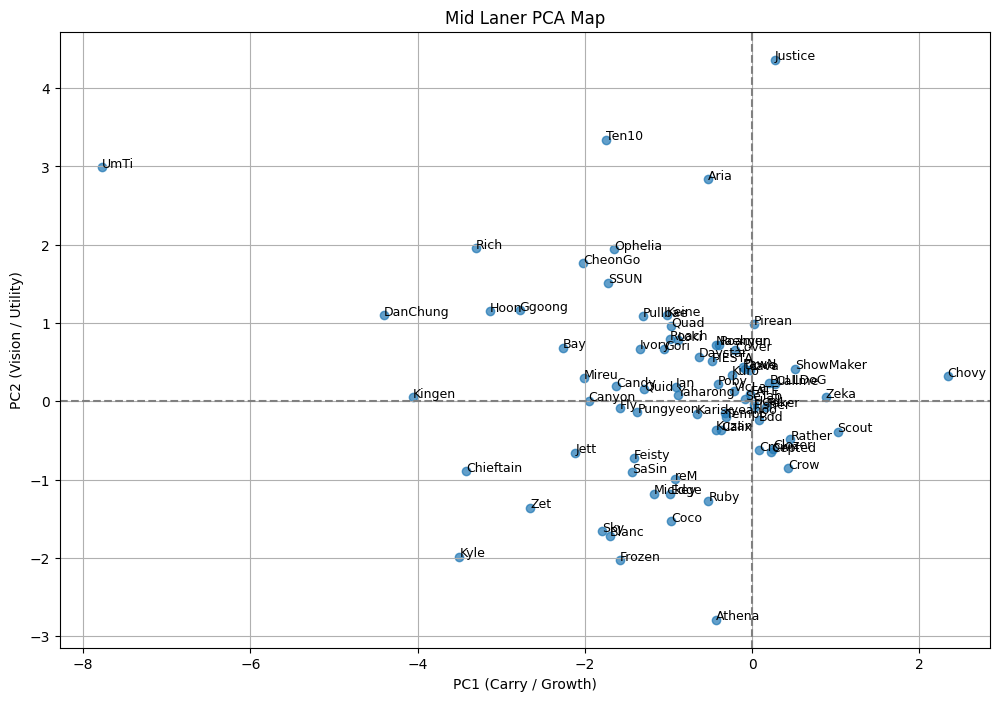

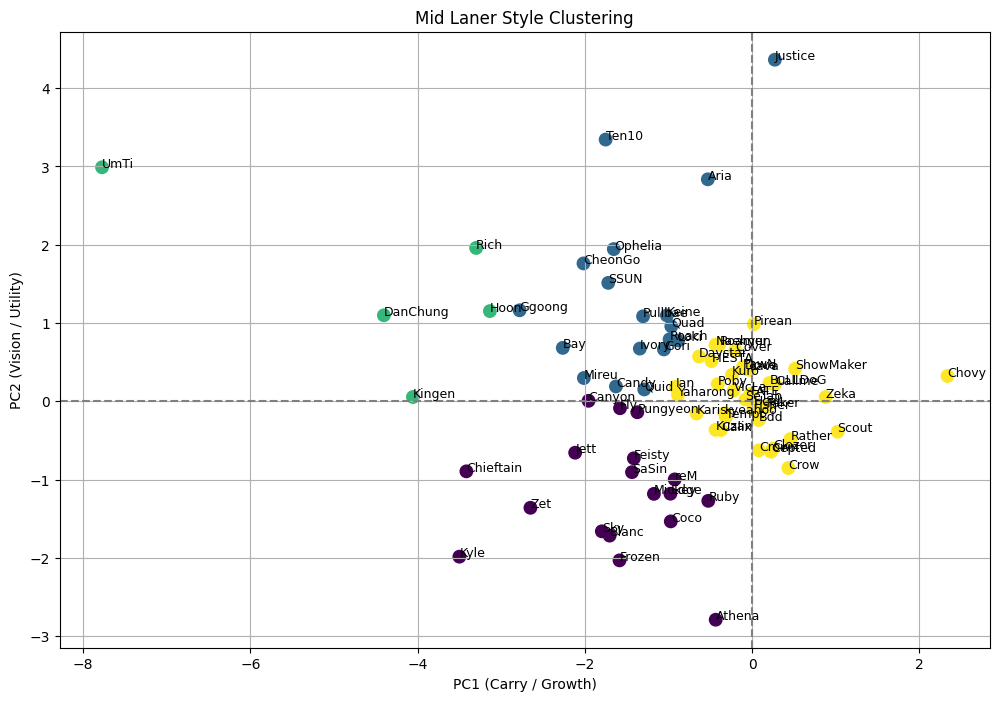


===== Cluster 0 =====
['Athena', 'Ruby', 'reM', 'Coco', 'Edge', 'Mickey', 'Pungyeon', 'Feisty', 'SaSin', 'Fly', 'Frozen', 'Blanc', 'Sky', 'Canyon', 'Jett', 'Zet', 'Chieftain', 'Kyle']

===== Cluster 1 =====
['Justice', 'Aria', 'Loki', 'Quad', 'Roach', 'Keine', 'Gori', 'Quid', 'Pullbae', 'Ivory', 'Candy', 'Ophelia', 'SSUN', 'Ten10', 'Mireu', 'CheonGo', 'Bay', 'Ggoong']

===== Cluster 2 =====
['Hoon', 'Rich', 'Kingen', 'DanChung', 'UmTi']

===== Cluster 3 =====
['Chovy', 'Scout', 'Zeka', 'ShowMaker', 'Rather', 'Crow', 'Callme', 'Clozer', 'Cepted', 'BuLLDoG', 'Faker', 'Crown', 'Bdd', 'Ucal', 'Pirean', 'Fisher', 'FATE', 'Lava', 'SeTab', 'Dove', 'PawN', 'Cover', 'VicLa', 'Kuro', 'Tempt', 'kyeahoo', 'Calix', 'Roamer', 'Poby', 'Kuzan', 'Naehyun', 'FIESTA', 'Daystar', 'Karis', 'Yaharong', 'Ian']

===== 프로 평균과 가장 가까운 선수 =====
            distance_from_pro_mean
playername                        
Yaharong                  0.400845
Quid                      0.666401
Ivory                     0.67

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

# =========================
# 1. 선수별 평균 PCA 좌표
# =========================

player_pca = mid_pca.groupby("playername")[["PC1", "PC2", "PC3"]].mean()

print(player_pca.head())

# =========================
# 2. PCA 2D 시각화
# =========================

plt.figure(figsize=(12, 8))

plt.scatter(
    player_pca["PC1"],
    player_pca["PC2"],
    alpha=0.7
)

# 선수 이름 표시
for player in player_pca.index:
    x = player_pca.loc[player, "PC1"]
    y = player_pca.loc[player, "PC2"]

    plt.text(
        x,
        y,
        player,
        fontsize=9
    )

plt.axhline(0, color='gray', linestyle='--')
plt.axvline(0, color='gray', linestyle='--')

plt.xlabel("PC1 (Carry / Growth)")
plt.ylabel("PC2 (Vision / Utility)")
plt.title("Mid Laner PCA Map")

plt.grid(True)
plt.show()

# =========================
# 3. KMeans 클러스터링
# =========================

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(
    player_pca[["PC1", "PC2"]]
)

player_pca["cluster"] = clusters

# =========================
# 4. 클러스터 시각화
# =========================

plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    player_pca["PC1"],
    player_pca["PC2"],
    c=player_pca["cluster"],
    s=80
)

for player in player_pca.index:
    x = player_pca.loc[player, "PC1"]
    y = player_pca.loc[player, "PC2"]

    plt.text(
        x,
        y,
        player,
        fontsize=9
    )

plt.axhline(0, color='gray', linestyle='--')
plt.axvline(0, color='gray', linestyle='--')

plt.xlabel("PC1 (Carry / Growth)")
plt.ylabel("PC2 (Vision / Utility)")
plt.title("Mid Laner Style Clustering")

plt.grid(True)
plt.show()

# =========================
# 5. 클러스터별 선수 확인
# =========================

for i in range(4):
    print(f"\n===== Cluster {i} =====")
    print(
        player_pca[player_pca["cluster"] == i]
        .sort_values("PC1", ascending=False)
        .index
        .tolist()
    )

# =========================
# 6. 프로 평균과 거리 계산
# =========================

# 프로 평균 좌표
pro_mean = player_pca[["PC1", "PC2", "PC3"]].mean()

# 거리 계산
player_pca["distance_from_pro_mean"] = np.sqrt(
    (player_pca["PC1"] - pro_mean["PC1"])**2 +
    (player_pca["PC2"] - pro_mean["PC2"])**2 +
    (player_pca["PC3"] - pro_mean["PC3"])**2
)

print("\n===== 프로 평균과 가장 가까운 선수 =====")
print(
    player_pca
    .sort_values("distance_from_pro_mean")
    [["distance_from_pro_mean"]]
    .head(20)
)

# =========================
# 7. 스타일 archetype 해석용 평균
# =========================

cluster_summary = player_pca.groupby("cluster")[["PC1", "PC2", "PC3"]].mean()

print("\n===== Cluster Summary =====")
print(cluster_summary)


#PCA 기반 미드라이너 클러스터링 결과 해석


#[1] Cluster Summary 해석

각 Cluster는 PCA 공간에서 비슷한 플레이 스타일을 가진 선수들을 묶은 결과이다.

PC1 = 성장력 / 캐리력
PC2 = 시야 / 운영 / Utility
PC3 = 교전 개입 / 위험 감수 성향

Cluster별 평균값은 다음과 같이 해석할 수 있다.

----------------------------------------
Cluster 0
----------------------------------------

- PC1: 낮음
- PC2: 낮음
- PC3: 낮음

→ 성장력, 운영 기여도, 교전 개입도가 전반적으로 낮은 그룹

→ 저성장 / 저운영형 또는 제한적 영향력 그룹으로 해석 가능


----------------------------------------
Cluster 1
----------------------------------------

- PC1: 낮음
- PC2: 높음
- PC3: 보통

→ 성장 dominance는 낮지만,
   시야와 운영 기여도가 높은 그룹

→ 운영 / Vision 중심형 미드라이너 그룹으로 해석 가능


----------------------------------------
Cluster 2
----------------------------------------

- PC1: 매우 낮음
- PC2: 높음
- PC3: 높음

→ 성장력은 낮지만,
   운영과 교전 개입 성향이 강한 그룹

→ 비정형 교전형 또는
   포지션 혼입 가능성이 있는 그룹으로 해석 가능


----------------------------------------
Cluster 3
----------------------------------------

- PC1: 평균에 가까움
- PC2: 평균에 가까움
- PC3: 약간 높음

→ 특정 한 축에 극단적으로 치우치지 않은
   밸런스형 그룹

→ Faker, Chovy, ShowMaker,
   Scout, Zeka, Bdd 등
   주요 미드라이너들이 포함됨

→ 완성형 / 밸런스형 엘리트 그룹으로 해석 가능



#[2] Cluster 3의 의미


Cluster 3에는 다음과 같은 대표적인
상위권 미드라이너들이 포함되었다.

- Chovy
- Faker
- ShowMaker
- Scout
- Zeka
- Bdd

이는 상위권 미드라이너들이
단순히 특정 지표 하나에만 특화된 것이 아니라,

- 성장력
- 운영력
- 교전 개입

등 여러 요소에서 균형 잡힌
프로파일을 가진다는 것을 시사한다.

특히 Chovy는 PC1이 매우 높게 나타났으며,
이는 실제 경기에서 보이는 강력한 라인전 및 성장 능력과 일치한다.


#[3] 프로 평균과의 거리 해석


프로 평균과 가장 가까운 선수들은 다음과 같이 나타났다.

- Yaharong
- Quid
- Ivory
- Fly
- Quad
- Poby
- Karis
- Naehyun
- Dove
- Gori

여기서 중요한 점은 다음과 같다.

프로 평균과 가까움은
반드시 실력이 가장 뛰어나다는 의미는 아니다.

이는 PCA 공간에서
극단적인 스타일을 보이지 않고,

전체 미드라이너 평균적인 플레이 스타일에
가깝다는 뜻이다.

반대로 Chovy처럼 특정 축에서
매우 강한 선수는 평균과의 거리가 더 멀어질 수 있다.

따라서 distance_from_pro_mean은
“실력 점수”라기보다는

“평균적인 프로 스타일과의 유사도”로
해석하는 것이 더 적절하다.


#[4] 분석상의 주의점


Cluster 2에는 Kingen, UmTi 등
실제로 미드라이너가 아닌 선수들이 포함되어 있다.

이는 데이터 필터링 과정에서
포지션 혼입이 발생했을 가능성을 의미한다.

따라서 최종 분석에서는 다음을 확인할 필요가 있다.

1. position 컬럼이 정확히 MID만 포함하는지 확인
2. 선수별 주 포지션이 미드인지 확인
3. 포지션이 다른 선수는 제거하거나 따로 표시
4. 경기 단위 데이터와 선수 단위 평균 데이터의 차이를 구분

이 과정을 거치면
클러스터 해석의 신뢰도를 높일 수 있다.


#[5] 프로젝트 관점에서의 의미


이번 PCA + KMeans 결과는
미드라이너의 플레이 스타일을
몇 개의 잠재 축(latent axis)으로 요약하고,

이를 바탕으로 선수 archetype을
분류할 수 있음을 보여준다.

즉 단순히 KDA나 승률만 보는 것이 아니라,

다양한 경기 지표를 압축하여
다음과 같은 잠재적인 플레이 스타일을
도출할 수 있다.

- 성장 / 캐리형
- 운영 / Vision 중심형
- 교전 개입형
- 밸런스형 엘리트 그룹

이는 선수의 잠재력 평가,
프로 평균과의 거리 측정,
선수 스타일 비교,
시즌별 성장 경로 분석 등에 활용 가능하다.



#[6] 결론


PCA 결과에서 PC1, PC2, PC3는 각각

- 성장력
- 운영력
- 교전 성향

이라는 해석 가능한 축으로 나타났다.

KMeans 클러스터링 결과는
이러한 PCA 축을 기반으로
미드라이너들을 서로 다른 플레이 스타일 그룹으로 분류하였다.

특히 주요 상위권 미드라이너들이
Cluster 3에 모였다는 점은,

엘리트 미드라이너들이
특정 지표 하나에만 의존하기보다

여러 능력치가 균형 잡힌 형태로 나타난다는 점을 시사한다.

따라서 본 분석은 미드라이너의 플레이 스타일과 잠재력을
설명 가능한 방식으로 수치화하는 데
유의미한 접근이라고 볼 수 있다.


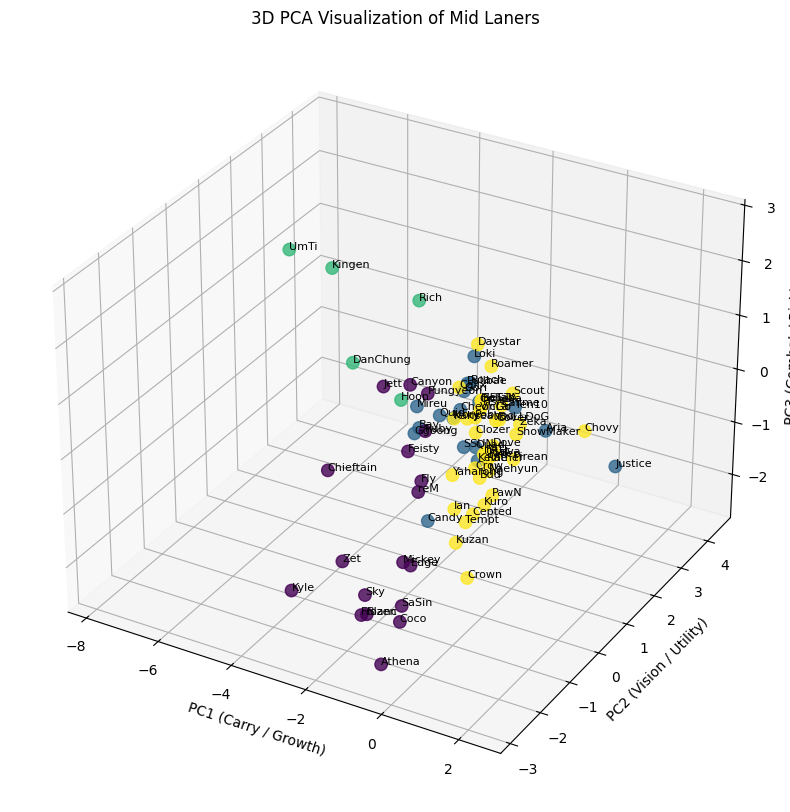

In [45]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

# 3D PCA 시각화
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# scatter
ax.scatter(
    player_pca["PC1"],
    player_pca["PC2"],
    player_pca["PC3"],
    c=player_pca["cluster"],
    s=80,
    alpha=0.8
)

# 선수 이름 표시
for player in player_pca.index:
    x = player_pca.loc[player, "PC1"]
    y = player_pca.loc[player, "PC2"]
    z = player_pca.loc[player, "PC3"]

    ax.text(
        x,
        y,
        z,
        player,
        fontsize=8
    )

# 축 라벨
ax.set_xlabel("PC1 (Carry / Growth)")
ax.set_ylabel("PC2 (Vision / Utility)")
ax.set_zlabel("PC3 (Combat / Risk)")

# 제목
ax.set_title("3D PCA Visualization of Mid Laners")

plt.show()

In [46]:
import plotly.express as px

# index를 컬럼으로 변환
plot_df = player_pca.reset_index()

# 3D interactive plot
fig = px.scatter_3d(
    plot_df,
    x="PC1",
    y="PC2",
    z="PC3",
    color="cluster",
    text="playername",
    title="Interactive 3D PCA Visualization of Mid Laners",
    width=1000,
    height=800
)

# 점 크기 및 텍스트 조정
fig.update_traces(
    marker=dict(size=6),
    textposition='top center'
)

# 축 이름 수정
fig.update_layout(
    scene=dict(
        xaxis_title='PC1 (Carry / Growth)',
        yaxis_title='PC2 (Vision / Utility)',
        zaxis_title='PC3 (Combat / Risk)'
    )
)

fig.show()

#AE

In [47]:
import pandas as pd
import numpy as np
import glob

from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# -----------------------------
# 1. 데이터 불러오기
# -----------------------------

files = sorted(glob.glob("/content/drive/MyDrive/전처리한 oracle 데이터/*.csv"))

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

# 미드만 사용
df = df[df["position"] == "mid"].copy()

# -----------------------------
# 2. Feature 선택
# -----------------------------

features = [
    "golddiffat15", "xpdiffat15", "csdiffat15",
    "goldat15", "xpat15", "csat15",
    "dpm", "damageshare",
    "damagetakenperminute", "damagemitigatedperminute",
    "visionscore", "vspm",
    "wardsplaced", "wardskilled",
    "wpm", "wcpm",
    "controlwardsbought",
    "earnedgold", "earned gpm", "earnedgoldshare",
    "cspm", "damagetotowers",
    "firstbloodkill", "firstbloodassist", "firstbloodvictim"
]

# 결측 제거
df = df.dropna(subset=features)

X = df[features].values

# -----------------------------
# 3. 정규화
# -----------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# 4. Tensor 변환
# -----------------------------

X_tensor = torch.FloatTensor(X_scaled)

dataset = TensorDataset(X_tensor)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

# -----------------------------
# 5. AutoEncoder 정의
# -----------------------------

class AutoEncoder(nn.Module):
    def __init__(self, input_dim, latent_dim=3):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),

            nn.Linear(16, 8),
            nn.ReLU(),

            nn.Linear(8, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 8),
            nn.ReLU(),

            nn.Linear(8, 16),
            nn.ReLU(),

            nn.Linear(16, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out

# -----------------------------
# 6. 모델 생성
# -----------------------------

input_dim = len(features)

model = AutoEncoder(input_dim=input_dim, latent_dim=3)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# -----------------------------
# 7. 학습
# -----------------------------

epochs = 100

for epoch in range(epochs):

    total_loss = 0

    for batch in loader:

        x = batch[0]

        reconstructed = model(x)

        loss = criterion(reconstructed, x)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

/tmp/ipykernel_545/2707355953.py:17: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



Epoch 1, Loss: 152.0930
Epoch 2, Loss: 122.8809
Epoch 3, Loss: 106.0953
Epoch 4, Loss: 96.7198
Epoch 5, Loss: 93.3187
Epoch 6, Loss: 89.1040
Epoch 7, Loss: 83.2607
Epoch 8, Loss: 81.5547
Epoch 9, Loss: 80.7721
Epoch 10, Loss: 80.1696
Epoch 11, Loss: 79.7697
Epoch 12, Loss: 79.4552
Epoch 13, Loss: 79.1745
Epoch 14, Loss: 78.9321
Epoch 15, Loss: 78.7063
Epoch 16, Loss: 78.5427
Epoch 17, Loss: 78.3692
Epoch 18, Loss: 78.2064
Epoch 19, Loss: 78.0827
Epoch 20, Loss: 77.9527
Epoch 21, Loss: 77.8063
Epoch 22, Loss: 77.6826
Epoch 23, Loss: 77.5826
Epoch 24, Loss: 77.4752
Epoch 25, Loss: 77.3327
Epoch 26, Loss: 77.2694
Epoch 27, Loss: 77.1276
Epoch 28, Loss: 77.0346
Epoch 29, Loss: 76.9056
Epoch 30, Loss: 76.7467
Epoch 31, Loss: 76.6454
Epoch 32, Loss: 76.5254
Epoch 33, Loss: 76.3721
Epoch 34, Loss: 76.2929
Epoch 35, Loss: 76.1201
Epoch 36, Loss: 76.0215
Epoch 37, Loss: 75.9086
Epoch 38, Loss: 75.7582
Epoch 39, Loss: 75.6574
Epoch 40, Loss: 75.4939
Epoch 41, Loss: 75.4040
Epoch 42, Loss: 75.222

In [48]:
with torch.no_grad():
    latent_vectors = model.encoder(X_tensor).numpy()

latent_df = pd.DataFrame(
    latent_vectors,
    columns=["Style1", "Style2", "Style3"]
)

result_df = pd.concat(
    [df.reset_index(drop=True), latent_df],
    axis=1
)

result_df.head(42)

,playername,teamname,position,patch,year,date,golddiffat15,xpdiffat15,csdiffat15,goldat15,...,firstbloodkill,firstbloodassist,firstbloodvictim,league,datacompleteness,gamelength,result,Style1,Style2,Style3
0,Frozen,Incredible Miracle,mid,5.15,2016,2015-09-11 08:58:54,300.0,339.0,-3.0,4763.0,...,0.0,0.0,0.0,LCK,complete,1744,1,-0.704141,4.097001,-4.788502
1,Kyle,Dark Wolves,mid,5.15,2016,2015-09-11 08:58:54,-300.0,-339.0,3.0,4463.0,...,0.0,0.0,0.0,LCK,complete,1744,0,-1.700235,5.138379,-5.820439
2,Kyle,Dark Wolves,mid,5.15,2016,2015-09-11 09:44:06,10.0,-129.0,-8.0,4838.0,...,0.0,0.0,0.0,LCK,complete,2030,1,0.175059,3.370069,-4.704123
3,Frozen,Incredible Miracle,mid,5.15,2016,2015-09-11 09:44:06,-10.0,129.0,8.0,4828.0,...,0.0,0.0,0.0,LCK,complete,2030,0,-1.347702,5.022347,-4.894656
4,Frozen,Incredible Miracle,mid,5.15,2016,2015-09-11 10:34:50,698.0,307.0,14.0,5217.0,...,0.0,0.0,0.0,LCK,complete,2217,1,1.854372,2.103054,-2.234718
5,Kyle,Dark Wolves,mid,5.15,2016,2015-09-11 10:34:50,-698.0,-307.0,-14.0,4519.0,...,0.0,0.0,0.0,LCK,complete,2217,0,-0.458751,2.465288,-4.834506
6,Kyle,Dark Wolves,mid,5.15,2016,2015-09-11 11:28:05,-685.0,-246.0,-12.0,4508.0,...,0.0,0.0,0.0,LCK,complete,1552,0,-1.281026,4.021488,-4.916471
7,Frozen,Incredible Miracle,mid,5.15,2016,2015-09-11 11:28:05,685.0,246.0,12.0,5193.0,...,0.0,0.0,0.0,LCK,complete,1552,1,0.795256,2.787260,-2.630344
8,SaSin,SBENU Korea,mid,5.15,2016,2015-09-12 08:45:27,-5.0,-83.0,1.0,5060.0,...,0.0,0.0,0.0,LCK,complete,2731,1,1.435101,1.108620,-3.456124
9,Athena,ESC Ever,mid,5.15,2016,2015-09-12 08:45:27,5.0,83.0,-1.0,5065.0,...,0.0,1.0,0.0,LCK,complete,2731,0,1.337189,0.948982,-3.041112


In [49]:
result_df.groupby("playername")[["Style1","Style2","Style3"]].mean()

,Style1,Style2,Style3
playername,,,
Aria,-3.147686,5.262042,2.644989
Athena,1.130108,1.319545,-2.381205
Bay,-3.395444,5.675513,-0.000443
Bdd,-1.624381,5.433992,0.952234
Blanc,0.551759,2.789126,-4.374455
...,...,...,...
Yaharong,-2.415451,4.938878,0.609143
Zeka,-1.657176,7.458490,1.848781
Zet,-0.077731,3.372052,-4.928831


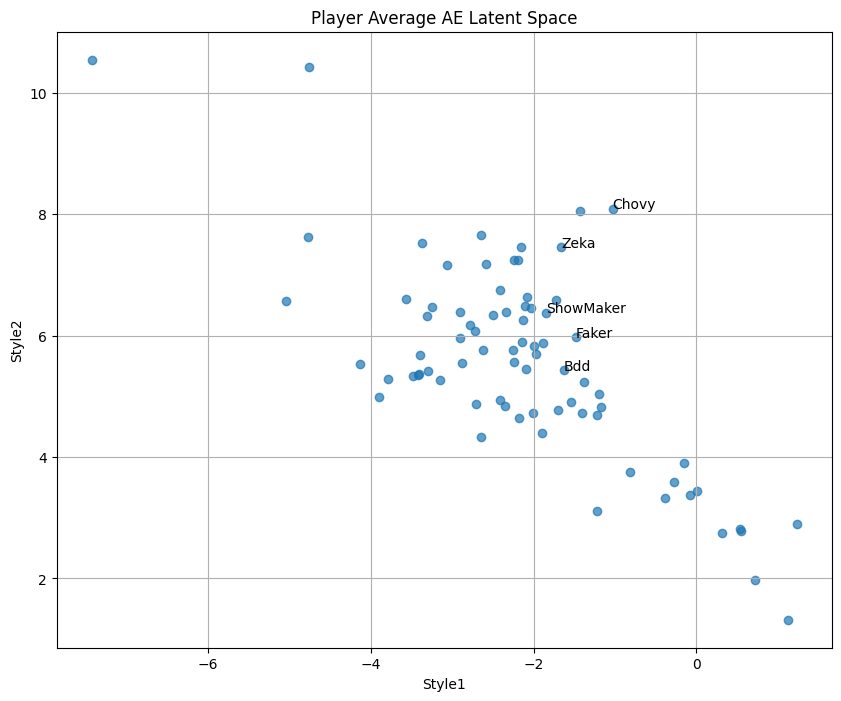

In [50]:
import matplotlib.pyplot as plt
player_latent = (
    result_df
    .groupby("playername")[["Style1", "Style2", "Style3"]]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 8))

plt.scatter(
    player_latent["Style1"],
    player_latent["Style2"],
    alpha=0.7
)

for _, row in player_latent.iterrows():
    if row["playername"] in ["Faker", "Chovy", "ShowMaker", "Bdd", "Zeka"]:
        plt.text(
            row["Style1"],
            row["Style2"],
            row["playername"],
            fontsize=10
        )

plt.xlabel("Style1")
plt.ylabel("Style2")
plt.title("Player Average AE Latent Space")
plt.grid(True)
plt.show()

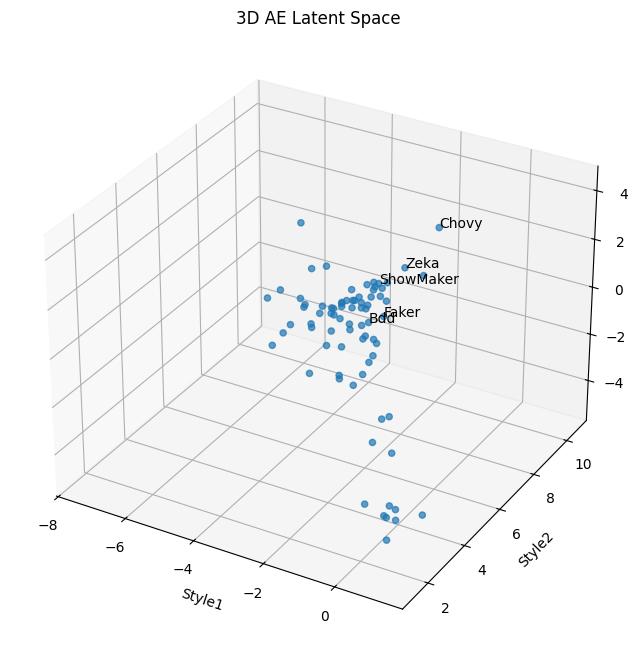

In [51]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    player_latent["Style1"],
    player_latent["Style2"],
    player_latent["Style3"],
    alpha=0.7
)

for _, row in player_latent.iterrows():
    if row["playername"] in ["Faker", "Chovy", "ShowMaker", "Bdd", "Zeka"]:
        ax.text(
            row["Style1"],
            row["Style2"],
            row["Style3"],
            row["playername"]
        )

ax.set_xlabel("Style1")
ax.set_ylabel("Style2")
ax.set_zlabel("Style3")
ax.set_title("3D AE Latent Space")

plt.show()

In [52]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [53]:
# PCA에서 사용한 동일한 X_scaled를 AE 입력으로 사용
X_tensor = torch.FloatTensor(X_scaled)

dataset = TensorDataset(X_tensor)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

class AutoEncoder(nn.Module):
    def __init__(self, input_dim, latent_dim=3):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        reconstructed = self.decoder(z)
        return reconstructed

In [54]:
input_dim = X_scaled.shape[1]
latent_dim = 3

model = AutoEncoder(input_dim=input_dim, latent_dim=latent_dim)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [55]:
epochs = 100
loss_history = []

for epoch in range(epochs):
    total_loss = 0

    for batch in loader:
        x = batch[0]

        reconstructed = model(x)
        loss = criterion(reconstructed, x)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    loss_history.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

Epoch 10/100, Loss: 0.4458
Epoch 20/100, Loss: 0.4104
Epoch 30/100, Loss: 0.3984
Epoch 40/100, Loss: 0.3910
Epoch 50/100, Loss: 0.3863
Epoch 60/100, Loss: 0.3825
Epoch 70/100, Loss: 0.3791
Epoch 80/100, Loss: 0.3759
Epoch 90/100, Loss: 0.3731
Epoch 100/100, Loss: 0.3705


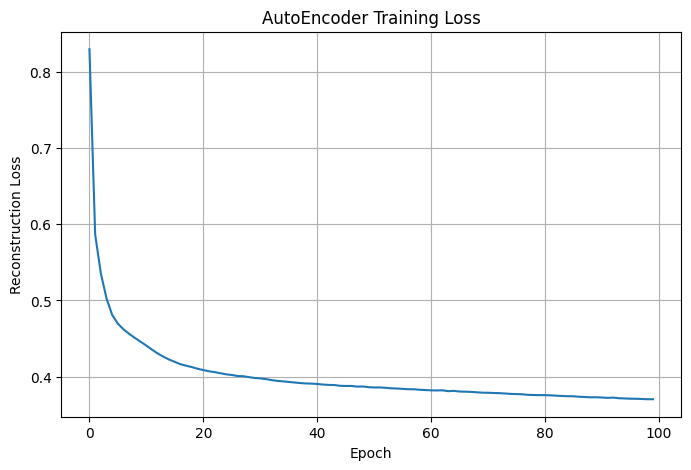

In [56]:
# 학습 과정 시각화
plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")
plt.title("AutoEncoder Training Loss")
plt.grid(True)
plt.show()

In [57]:
# AE latent vector 추출
model.eval()

with torch.no_grad():
    latent_vectors = model.encoder(X_tensor).numpy()

df["AE1"] = latent_vectors[:, 0]
df["AE2"] = latent_vectors[:, 1]
df["AE3"] = latent_vectors[:, 2]

In [58]:
# 선수별 AE latent 평균
ae_player = (
    df.groupby("playername")[["AE1", "AE2", "AE3"]]
    .mean()
    .reset_index()
)

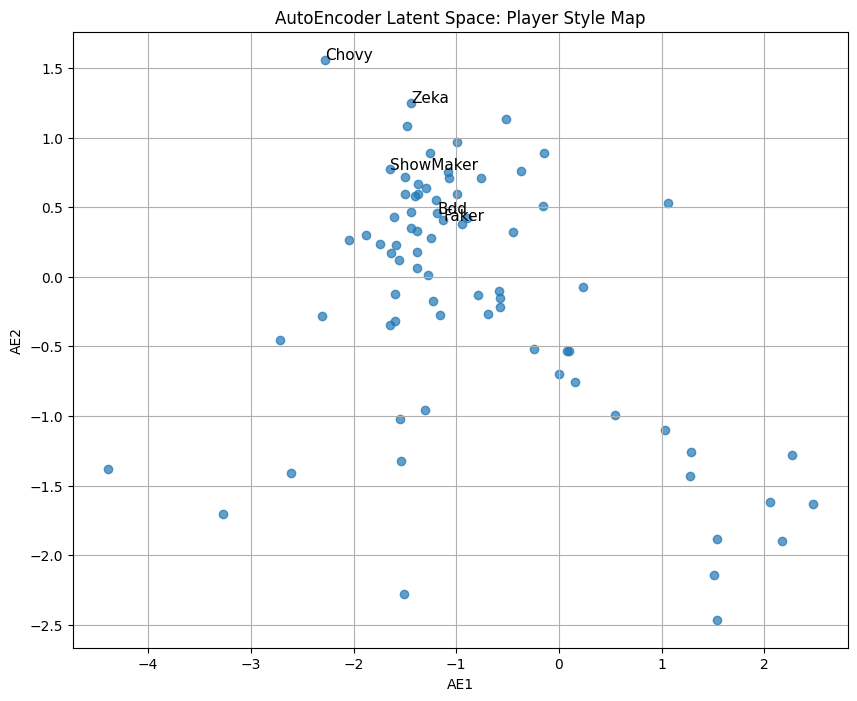

In [59]:
# AE latent space 2D 시각화
plt.figure(figsize=(10, 8))

plt.scatter(
    ae_player["AE1"],
    ae_player["AE2"],
    alpha=0.7
)

target_players = ["Faker", "Chovy", "ShowMaker", "Bdd", "Zeka"]

for _, row in ae_player.iterrows():
    if row["playername"] in target_players:
        plt.text(
            row["AE1"],
            row["AE2"],
            row["playername"],
            fontsize=11
        )

plt.xlabel("AE1")
plt.ylabel("AE2")
plt.title("AutoEncoder Latent Space: Player Style Map")
plt.grid(True)
plt.show()

In [61]:
from sklearn.decomposition import PCA

# PCA도 AE와 동일하게 X_scaled 사용
pca = PCA(n_components=3)
pca_vectors = pca.fit_transform(X_scaled)

# df에 PCA 결과 추가
df["PC1"] = pca_vectors[:, 0]
df["PC2"] = pca_vectors[:, 1]
df["PC3"] = pca_vectors[:, 2]

# 설명된 분산 비율 확인
pca_explained = pd.DataFrame({
    "PC": ["PC1", "PC2", "PC3"],
    "Explained_Variance_Ratio": pca.explained_variance_ratio_,
    "Cumulative": np.cumsum(pca.explained_variance_ratio_)
})

pca_explained

,PC,Explained_Variance_Ratio,Cumulative
0,PC1,0.246507,0.246507
1,PC2,0.130183,0.376690
2,PC3,0.091561,0.468251


In [62]:
# PCA 결과와 연결해서 비교하기
# PCA 코드에서 df["PC1"], df["PC2"], df["PC3"]가 이미 있다고 가정

pca_player = (
    df.groupby("playername")[["PC1", "PC2", "PC3"]]
    .mean()
    .reset_index()
)

compare_player = pd.merge(
    pca_player,
    ae_player,
    on="playername",
    how="inner"
)

compare_player.head()

,playername,PC1,PC2,PC3,AE1,AE2,AE3
0,Aria,-0.530855,2.835424,-0.882507,-2.714864,-0.452287,0.824332
1,Athena,-0.436787,-2.791129,-2.299610,1.285668,-1.258167,-4.509494
2,Bay,-2.265387,0.681959,-0.120908,-0.584190,-0.100284,0.263539
3,Bdd,0.078621,-0.239973,-0.109410,-1.184352,0.456904,-0.762106
4,Blanc,-1.705261,-1.716664,-2.237437,2.051653,-1.618332,-5.179770


In [63]:
# PCA와 AE latent 축의 상관관계 확인
corr_pca_ae = compare_player[
    ["PC1", "PC2", "PC3", "AE1", "AE2", "AE3"]
].corr()

corr_pca_ae.loc[["PC1", "PC2", "PC3"], ["AE1", "AE2", "AE3"]]

,AE1,AE2,AE3
PC1,-0.429716,0.546623,-0.097136
PC2,-0.697806,0.007701,0.695977
PC3,-0.435886,0.666258,0.720570


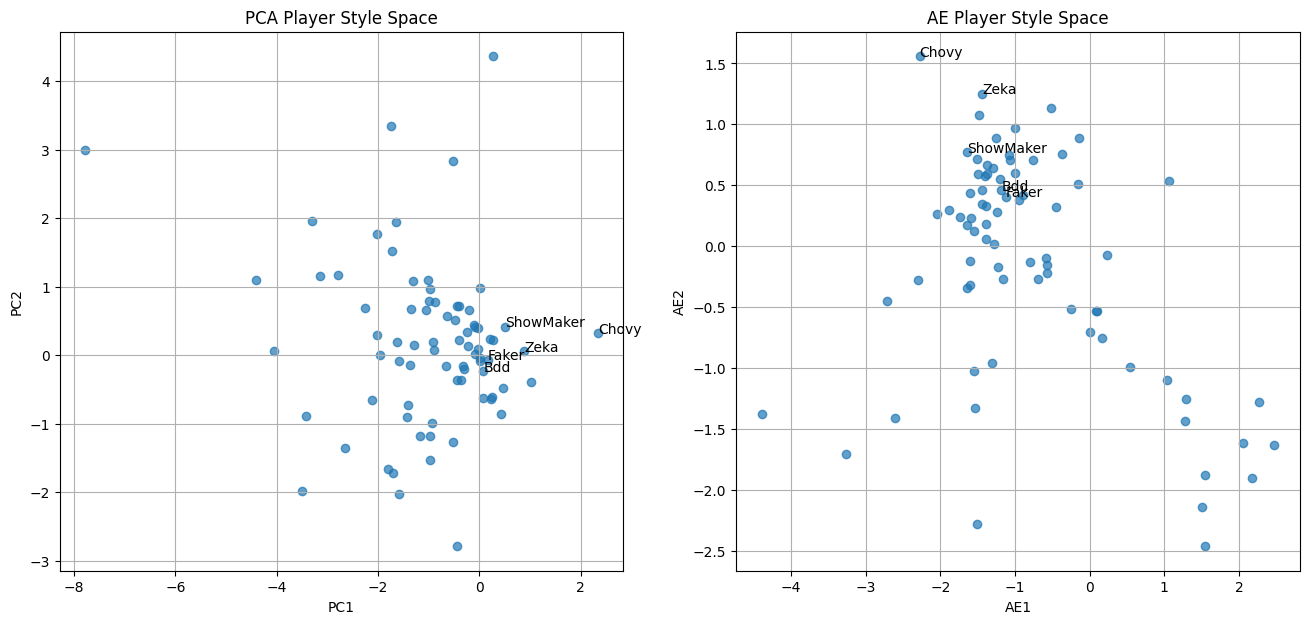

In [64]:
# PCA 공간과 AE 공간을 나란히 비교
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].scatter(compare_player["PC1"], compare_player["PC2"], alpha=0.7)
axes[0].set_title("PCA Player Style Space")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].grid(True)

axes[1].scatter(compare_player["AE1"], compare_player["AE2"], alpha=0.7)
axes[1].set_title("AE Player Style Space")
axes[1].set_xlabel("AE1")
axes[1].set_ylabel("AE2")
axes[1].grid(True)

for _, row in compare_player.iterrows():
    if row["playername"] in target_players:
        axes[0].text(row["PC1"], row["PC2"], row["playername"], fontsize=10)
        axes[1].text(row["AE1"], row["AE2"], row["playername"], fontsize=10)

plt.show()

In [65]:
# AE latent 축이 원래 feature와 어떤 관련이 있는지 확인
ae_feature_corr = df[features + ["AE1", "AE2", "AE3"]].corr()

ae_feature_corr.loc[features, ["AE1", "AE2", "AE3"]]

,AE1,AE2,AE3
golddiffat15,-0.064348,0.393707,-0.169473
xpdiffat15,-0.103106,0.318421,-0.143223
csdiffat15,-0.145500,0.265203,-0.177242
goldat15,-0.139703,0.418752,-0.135319
xpat15,-0.211014,0.363050,-0.009336
csat15,-0.273313,0.344589,0.014844
dpm,-0.090286,0.249335,-0.123821
damageshare,-0.035200,0.132027,-0.197740
damagetakenperminute,0.073088,0.142382,0.207592
damagemitigatedperminute,-0.160444,0.332165,0.531988


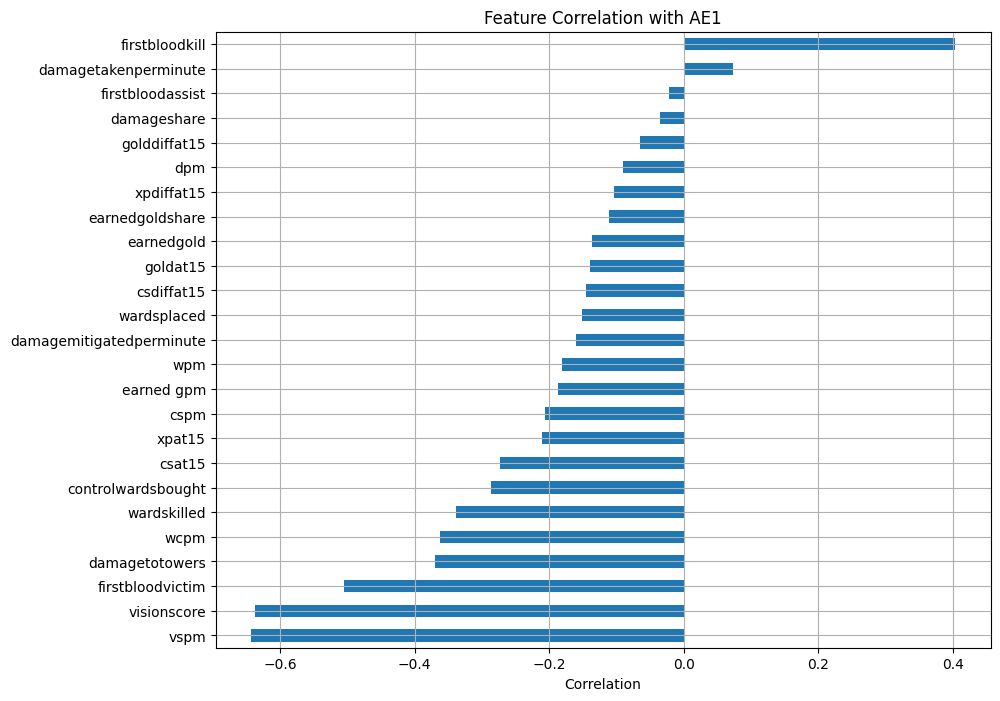

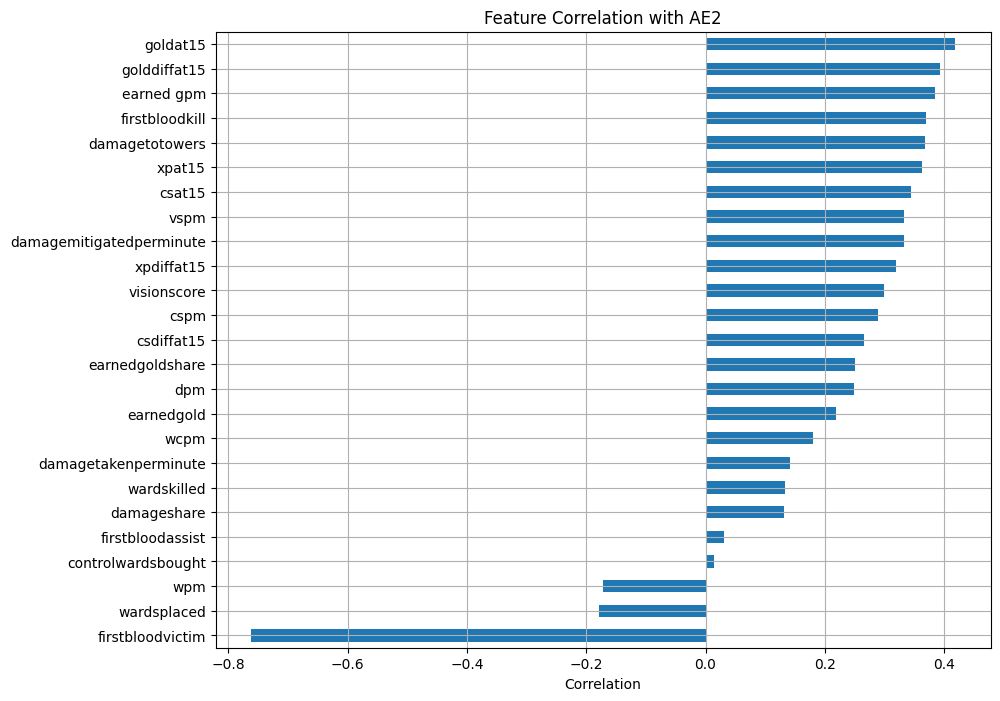

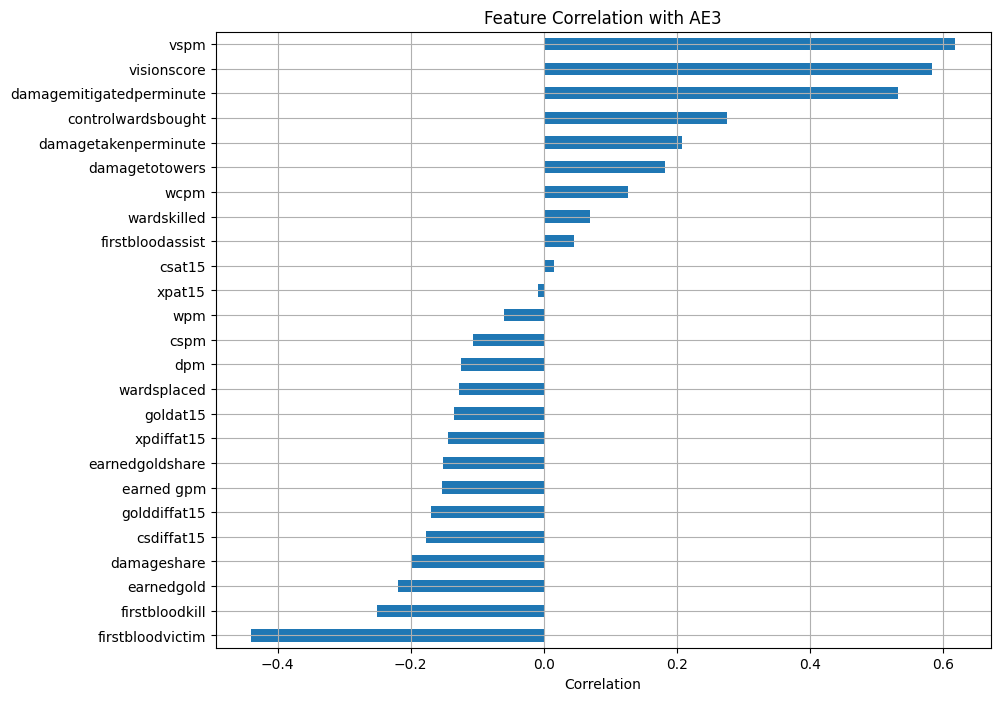

In [66]:
# AE1과 강하게 관련된 feature 시각화
plt.figure(figsize=(10, 8))
ae_feature_corr["AE1"].loc[features].sort_values().plot(kind="barh")
plt.title("Feature Correlation with AE1")
plt.xlabel("Correlation")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 8))
ae_feature_corr["AE2"].loc[features].sort_values().plot(kind="barh")
plt.title("Feature Correlation with AE2")
plt.xlabel("Correlation")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 8))
ae_feature_corr["AE3"].loc[features].sort_values().plot(kind="barh")
plt.title("Feature Correlation with AE3")
plt.xlabel("Correlation")
plt.grid(True)
plt.show()